<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

The overall goal of SurEau soil hydraulics is calculate the soil water potential 
and soil water conductivity given the amount of water (mm) available

In [0]:
#| echo: false
#| output: asis
show_doc(compute_soil_VG)

---

[source](https://github.com/ecamo19/plant_hydraulics/blob/main/plant_hydraulics/sureau_soil_hydraulics.py#L14){target="_blank" style="float:right; font-size:smaller"}

### compute_soil_VG

```python

def compute_soil_VG(
    soil:SurEauSoil, params:SurEauSoilParams
)->SurEauSoil:


```

*Van Genuchten: transform soil moisture → water potential & conductance.*

ANALOGY — The Sponge Squeeze:

Imagine each soil layer is a sponge sitting in a bucket.

REW (Relative Extractable Water) tells you what fraction of the sponge's
usable capacity is still filled.

REW = 1 means soaking wet, REW = 0 means only residual water trapped in the
tiniest pores remains.

k_soil (hydraulic conductance) tells you how fast water can flow through
that sponge. A wet sponge lets water through easily; a nearly dry one barely
lets anything pass.

psi_soil (water potential) tells you how hard the sponge is gripping its
remaining water. A wet sponge barely holds on (ψ ≈ 0); a dry sponge clings
to the last drops with enormous force (ψ << 0).

Equations implemented:
  REW      = (stock - residual) / (saturation - residual)     [Eq. 22]
  k_soil   = Ksat × B_GC × REW^I × (1-(1-REW^(1/m))^m)²    [Eq. 21 variant]
  psi_soil = -((1/REW)^(1/m) - 1)^(1/n) / (α × 10000)      [Eq. 48]

```
 INPUTS
 ──────
   soil.soil_water_stock        [mm per layer]  — current water
   params.V_saturation_capacity [mm per layer]  — max capacity
   params.V_residual_capacity   [mm per layer]  — trapped water
   params.alpha_vg              [cm⁻¹]          — air-entry
   params.n_vg                  [−]             — pore-size index
   params.m = 1 − 1/n           [−]             — derived shape
   params.I_vg                  [−]             — tortuosity
   params.Ksat                  [mmol/m/s/MPa]  — saturated K
   params.B_GC                  [−]             — root geometry
   params.offset_psoil          [MPa]           — calibration shift

                         │
                         ▼
┌─────────────────────────────────────────────────────────┐
│                                                         │
│             EQUATION 22: REW (per layer)                │
│          "What fraction of usable water remains?"       │
│                                                         │
│   max_water = V_saturation − V_residual                 │
│   eff_water = soil_water_stock − V_residual             │
│                                                         │
│              eff_water                                  │
│   REW  =  ───────────    clipped to [0.0001, 1.0]       │
│              max_water                                  │
│                                                         │
│   REW = 1.0  → fully saturated                          │
│   REW = 0.5  → half the usable water remains            │
│   REW = 0.0  → only residual water left                 │
│                                                         │
└────────────────────────┬────────────────────────────────┘
                         │
              ┌──────────┴──────────┐
              ▼                     ▼
┌──────────────────────────┐ ┌─────────────────────────────────┐
│                          │ │                                 │
│   EQUATION 21: k_soil    │ │   EQUATION 48: ψ_soil           │
│   (per layer)            │ │   (per layer)                   │
│   "How easily can water  │ │   "How tightly is the           │
│    flow to the roots?"   │ │    remaining water held?"       │
│                          │ │                                 │
│                          │ │  Given: REW, α, n, m = 1−1/n    │
│  PART A: relative K      │ │                                 │
│  (Mualem-VG, 0 to 1)     │ │  Step 1: Invert saturation      │
│                          │ │          x₁ = 1 / REW           │
│  Factor 1: Tortuosity    │ │                                 │
│  ┌─────────────────────┐ │ │    wet  REW=1.0 → x₁ = 1        │
│  │  REW ^ I_vg         │ │ │    half REW=0.5 → x₁ = 2        │
│  │                     │ │ │    dry  REW=0.1 → x₁ = 10       │
│  │  Water must detour  │ │ │                                 │
│  │  around air-filled  │ │ │  Step 2: Apply VG shape         │
│  │  pores. Fewer water │ │ │          x₂ = x₁ ^ (1/m)        │
│  │  channels = more    │ │ │                                 │
│  │  detours.           │ │ │    Since m<1, exponent 1/m > 1  │
│  └─────────────────────┘ │ │    This AMPLIFIES dryness       │
│            ×             │ │                                 │
│  Factor 2: Connectivity  │ │  Step 3: Zero at saturation     │
│  ┌─────────────────────┐ │ │          x₃ = x₂ − 1            │
│  │                     │ │ │                                 │
│  │ [1 − (1 − REW       │ │ │    When REW=1: x₃=0 → ψ=0       │
│  │    ^(1/m)) ^ m]²    │ │ │    (no suction when saturated)  │
│  │                     │ │ │                                 │
│  │ As soil dries, big  │ │ │  Step 4: Pore-size scaling      │
│  │ pores drain first,  │ │ │          x₄ = x₃ ^ (1/n)        │
│  │ remaining paths     │ │ │                                 │
│  │ disconnect.         │ │ │    n controls steepness:        │
│  │ Squaring from       │ │ │    high n (sand) → steep drop   │
│  │ Mualem (1976).      │ │ │    low n  (clay) → gradual drop │
│  └─────────────────────┘ │ │                                 │
│            =             │ │  Step 5: Air-entry pressure     │
│         k_temp           │ │          x₅ = x₄ / α            │
│                          │ │                                 │
│                          │ │    α (cm⁻¹) ≈ inverse of the    │
│  PART B: absolute K      │ │    pressure needed to push air  │
│  (scale to real units)   │ │    into the largest pores       │
│                          │ │    Result is in cm H₂O          │
│  k_soil = 1000           │ │                                 │
│         × Ksat           │ │  Step 6: Unit conversion        │
│         × B_GC           │ │          x₆ = x₅ / 10000        │
│         × k_temp         │ │                                 │
│                          │ │    cm H₂O → MPa                 │
│  where B_GC comes from   │ │    (1 MPa ≈ 10197 cm ≈ 10000)   │
│  init_par_soil():        │ │                                 │
│                          │ │  Step 7: Sign and offset        │
│    B_GC = La × 2π        │ │          ψ = −x₆ − offset       │
│          ──────────      │ │                                 │
│          ln(b / r_root)  │ │    Negate: suction ≤ 0          │
│                          │ │    Offset: calibration          │
│                          │ │         (usually 0)             │
│  (Gardner-Cowan root     │ │                                 │
│   geometry factor,       │ │  In code (one line):            │
│   Eq. 21 in the paper)   │ │  ψ = −((1/REW)^(1/m)−1)^(1/n)   │
│                          │ │      / α / 10000 − offset       │
│                          │ │                                 │
│  Result examples:        │ │  Result examples:               │
│  (loam, I=0.5)           │ │  (loam, α=0.0005, n=1.55)       │
│                          │ │                                 │
│  REW=1.00 → k_temp=1.00  │ │  REW=1.00 → ψ =  0.000 MPa      │
│  REW=0.50 → k_temp=0.11  │ │  REW=0.50 → ψ = −0.068 MPa      │
│  REW=0.10 → k_temp=0.001 │ │  REW=0.20 → ψ = −0.437 MPa      │
│                          │ │  REW=0.05 → ψ = −3.976 MPa      │
│  Units: mmol/m²/s/MPa    │ │  REW=0.01 → ψ = −41.56 MPa      │
│                          │ │                                 │
│                          │ │  Units: MPa (always ≤ 0)        │
│                          │ │                                 │
└────────────┬─────────────┘ └───────────────┬─────────────────┘
             │                               │
             ▼                               ▼
       Used by solver:                 Used by solver:
       update_kplant()                 sureau_solver()
             │                               │
             ▼                               ▼
       Eq. 20: k_soil_to_stem         Eqs. 5,10,11,12:
       = series(k_soil, k_RSApo)      ψ_soil is boundary
       "plumbing from soil             condition for water
        through roots"                 uptake gradients
             │                               │
             └───────────────┬───────────────┘
                             │
                             ▼

 OUTPUTS
 ───────
   soil.REW        [− per layer]       → used by evaporation
   soil.k_soil     [mmol/m²/s/MPa]     → used by solver (Eq. 20)
   soil.psi_soil   [MPa per layer]     → used by solver (Eqs. 5–12)
   soil.RWC        [− whole profile]   → diagnostic
   soil.REW_tot    [− whole profile]   → diagnostic
   soil.REW_wp     [− whole profile]   → diagnostic

```

In [0]:
#| echo: false
#| output: asis
show_doc(compute_soil_Campbell)

---

[source](https://github.com/ecamo19/plant_hydraulics/blob/main/plant_hydraulics/sureau_soil_hydraulics.py#L126){target="_blank" style="float:right; font-size:smaller"}

### compute_soil_Campbell

```python

def compute_soil_Campbell(
    soil:SurEauSoil, params:SurEauSoilParams
)->SurEauSoil:


```

*Campbell kSoil and PsiSoil using a ower-law relationships*
ψ = ψ_e × (θ/θ_s)^(−b)
K = K_sat × (θ/θ_s)^(2b+3)

Transform soil moisture into water potential and k conductance

```
    soil.soil_water_stock (mm per layer)
    params.V_saturation_capacity (mm per 
    layer)
                    │
                    ▼
      ┌──────────────────────────────┐
      │  SATURATION RATIO (per       │
      │  layer) ratio = SWS / V_sat  │       
      │  (0 = bone dry, 1 = full)    │
      └─────────────┬────────────────┘
                    │
            ┌───────┴───────┐
            ▼               ▼
    ┌────────────┐  ┌───────────────┐
    │  k_soil    │  │  ψ_soil       │
    │            │  │               │
    │ ratio^     │  │ −ψ_e ×        │
    │ (2−2b)     │  │ ratio^(−b)    │
    │            │  │ − offset      │
    │ ⚠ MISSING: │  │               │
    │ × Ksat×B_GC│  │ Units: MPa    │
    │ (BUG?)     │  │               │
    └─────┬──────┘  └──────┬────────┘
          │                │
          ▼                ▼
  Used by solver    Used by solver
  (how easily       (how tightly
   water flows)      water is held)
```                

In [0]:
#| echo: false
#| output: asis
show_doc(compute_soil_conductance_and_psi)

---

[source](https://github.com/ecamo19/plant_hydraulics/blob/main/plant_hydraulics/sureau_soil_hydraulics.py#L171){target="_blank" style="float:right; font-size:smaller"}

### compute_soil_conductance_and_psi

```python

def compute_soil_conductance_and_psi(
    soil:SurEauSoil, params:SurEauSoilParams
)->SurEauSoil:


```

*Dispatch to VG or Campbell.*

In [0]:
#| echo: false
#| output: asis
show_doc(compute_infiltration)

---

[source](https://github.com/ecamo19/plant_hydraulics/blob/main/plant_hydraulics/sureau_soil_hydraulics.py#L185){target="_blank" style="float:right; font-size:smaller"}

### compute_infiltration

```python

def compute_infiltration(
    soil:SurEauSoil, params:SurEauSoilParams, ppt_soil, cst_infil:float=0.7
)->SurEauSoil:


```

*Infiltration through soil layers, then update psi/k.*

ANALOGY — Stacked Buckets:

Picture 3 buckets stacked on top of each other, each with a small
hole at the bottom.

Phase 1 Percolation (slow drip):
  Before rain arrives, any bucket already above its "comfortable full"
  line (field capacity) slowly drips into the one below.

  The cst_infil parameter (0.7) means 70% of the excess drips per
  timestep, not everything at once, like a slow leak.

Phase 2 Add rainfall:
  Pour the rain into the top bucket.

Phase 3 Surcharge (overflow):
  If any bucket is now above its absolute maximum (saturation), the
  excess instantly spills into the bucket below.  The bottom bucket's
  overflow becomes deep drainage — water lost from the system.

```
Previous timestep's soil water
           │
           ▼
  ┌──────────────────┐
  │ PERCOLATION LOOP │  ← Drain excess above field capacity (70% per step)
  │ (gravity drain)  │     Water cascades downward layer by layer
  └────────┬─────────┘
           │
           ▼
  ┌──────────────────┐
  │  ADD RAINFALL    │  ← Throughfall enters top layer
  └────────┬─────────┘
           │
           ▼
  ┌──────────────────┐
  │  SURCHARGE LOOP  │  ← Drain ALL excess above saturation capacity
  │  (overflow)      │     Water cascades downward layer by layer
  └────────┬─────────┘
           │
           ▼
  Save SWS, compute drainage,
  update ψ_soil and 
  ```

In [0]:
#| echo: false
#| output: asis
show_doc(update_soil_water)

---

[source](https://github.com/ecamo19/plant_hydraulics/blob/main/plant_hydraulics/sureau_soil_hydraulics.py#L280){target="_blank" style="float:right; font-size:smaller"}

### update_soil_water

```python

def update_soil_water(
    soil:SurEauSoil, params:SurEauSoilParams, flux_evap
)->SurEauSoil:


```

*Subtract transpiration flux from soil and update.*

In [0]:
#| echo: false
#| output: asis
show_doc(set_SWC_to_field_capacity)

---

[source](https://github.com/ecamo19/plant_hydraulics/blob/main/plant_hydraulics/sureau_soil_hydraulics.py#L290){target="_blank" style="float:right; font-size:smaller"}

### set_SWC_to_field_capacity

```python

def set_SWC_to_field_capacity(
    soil:SurEauSoil, params:SurEauSoilParams, layers:NoneType=None
)->SurEauSoil:


```

*Reset soil water stock to field capacity.*

ANALOGY — Refilling the Sponge:

After a long rainy spell, the soil drains freely until each layer
reaches its "comfortable full" level — field capacity.  This function
is the equivalent of saying "pretend it just rained enough to fill
the sponge back to its comfortable level."

In [0]:
#| echo: false
#| output: asis
show_doc(compute_evaporation)

---

[source](https://github.com/ecamo19/plant_hydraulics/blob/main/plant_hydraulics/sureau_soil_hydraulics.py#L313){target="_blank" style="float:right; font-size:smaller"}

### compute_evaporation

```python

def compute_evaporation(
    soil:SurEauSoil, params:SurEauSoilParams, T_air, RH_air, N_hours
)->SurEauSoil:


```

*Soil surface evaporation (Equation 35).*

ANALOGY — Drying the Top of the Sponge:

Only the TOP bucket loses water to the atmosphere directly.  How fast
it dries depends on:
  - How dry the air is (VPD — the "thirst" of the atmosphere)
  - How wet the top layer still is (REW₁ — a self-limiting brake)
  - How breathable the soil surface is (g_soil0)

On a hot dry day with wet topsoil: evaporation is high.
On a humid day with dry topsoil: evaporation is negligible.

Equation 35: E_soil = g_soil0 × REW₁ × VPD / P_atm

```
Soil surface evaporation (topsoil only)
Paper: Equation 35, Section 2.4.2


 INPUTS
 ──────
   T_air        [°C]              — air temperature this timestep
   RH_air       [%]               — air relative humidity
   N_hours      [hours]           — duration of this timestep
   soil.ETP     [mm]              — potential ET allocated to soil
   soil.REW[0]  [−]               — topsoil relative extractable water
   params.g_soil0 [mmol/m²soil/s] — max soil vapor conductance

                         │
                         ▼
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│  STEP 1: Estimate soil surface temperature                  │
│  (empirical regression, fitted at O3HP France)              │
│                                                             │
│     T_soil = 0.6009 × T_air + 3.59                          │
│                                                             │
│     Example: T_air = 30°C → T_soil = 21.6°C                 │
│                                                             │
│     Why? Soil is cooler than air due to thermal             │
│     inertia — the evaporating surface temperature           │
│     sets the saturation vapor pressure.                     │
│                                                             │
└────────────────────────┬────────────────────────────────────┘
                         │
                         ▼
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│  STEP 2: Compute VPD at the soil surface                    │
│                                                             │
│     VPD_soil = e_sat(T_soil) − e_air(RH_air, T_soil)        │
│                                                             │
│     e_sat at SOIL temperature (evaporating surface)         │
│     e_air from AIR humidity (atmosphere above)              │
│                                                             │
│     Units: kPa                                              │
│                                                             │
└────────────────────────┬────────────────────────────────────┘
                         │
                         ▼
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│  STEP 3: Frozen soil check                                  │
│                                                             │
│                  T_soil < 0 °C ?                            │
│                 ╱             ╲                             │
│               YES              NO                           │
│                │                │                           │
│                ▼                ▼                           │
│     evaporation = 0     continue to Step 4                  │
│     (ice doesn't                                            │
│      evaporate                                              │
│      in this model)                                         │
│                                                             │
└────────────────────────┬────────────────────────────────────┘
                         │ (T_soil ≥ 0)
                         ▼
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│  STEP 4: VPD-limited evaporation rate                       │
│  ═══════════════════════════════════                        │
│  EQUATION 35 from the paper                                 │
│                                                             │
│              g_soil0 × REW₁ × VPD_soil                      │
│    E_VPD = ─────────────────────────────                    │
│                      P_atm                                  │
│                                                             │
│  ┌───────────────────────────────────────────────────┐      │
│  │  g_soil0     Max soil vapor conductance           │      │
│  │              "How breathable is the soil          │      │
│  │               surface when fully wet?"            │      │
│  │              [mmol/m²soil/s]                      │      │
│  ├───────────────────────────────────────────────────┤      │
│  │  REW[0]      Topsoil relative extractable water   │      │
│  │              "How wet is the top layer?"          │      │
│  │              Scales conductance: dry soil         │      │
│  │              self-limits its own evaporation      │      │
│  │              [−, 0 to 1]                          │      │
│  ├───────────────────────────────────────────────────┤      │
│  │  VPD_soil    Vapor pressure deficit at surface    │      │
│  │              "How thirsty is the air?"            │      │
│  │              [kPa]                                │      │
│  ├───────────────────────────────────────────────────┤      │
│  │  P_atm       Atmospheric pressure = 101.3         │      │
│  │              Converts conductance to flux         │      │
│  │              [kPa]                                │      │
│  └───────────────────────────────────────────────────┘      │
│                                                             │
│  Result: E_VPD [mmol/m²soil/s]                              │
│  "How fast the soil WANTS to evaporate"?                    │
│                                                             │
└────────────────────────┬────────────────────────────────────┘
                         │
                         ▼
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│  STEP 5: ETP-limited evaporation rate                       │
│  ════════════════════════════════════                       │
│  (operational constraint, not a paper equation)             │
│                                                             │
│  Sub-step A: Convert ETP from mm to mmol/m²/s               │
│                                                             │
│                    soil.ETP × 1e6                           │
│    ETP_mmol_s = ─────────────────────                       │
│                  3600 × N_hours × 18                        │
│                                                             │
│    ┌───────────────────────────────────────────┐            │
│    │  soil.ETP    PET allocated to soil [mm]   │            │
│    │              (split from total ETP        │            │
│    │               upstream using LAI)         │            │
│    ├───────────────────────────────────────────┤            │
│    │  1e6         mm → µL/m² (≈ µg/m²)         │            │
│    ├───────────────────────────────────────────┤            │
│    │  3600×N_hours  hours → seconds            │            │
│    ├───────────────────────────────────────────┤            │
│    │  18          molar mass of H₂O [g/mol]    │            │
│    └───────────────────────────────────────────┘            │
│                                                             │
│  Sub-step B: Scale by topsoil moisture                      │
│                                                             │
│    E_ETP = ETP_mmol_s × REW[0]                              │
│                                                             │
│    "Even with unlimited energy, can't evaporate             │
│     water that isn't there"                                 │
│                                                             │
│  Result: E_ETP [mmol/m²soil/s]                              │
│  "How fast the ENERGY BUDGET allows evaporation"            │
│                                                             │
└────────────────────────┬────────────────────────────────────┘
                         │
                         ▼
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│  STEP 6: Take the binding constraint                        │
│                                                             │
│    E_soil = min( E_VPD , E_ETP )                            │
│                                                             │
│  ┌──────────────────────┬──────────────────────────┐        │
│  │  Scenario            │  Which binds?            │        │
│  ├──────────────────────┼──────────────────────────┤        │
│  │  Humid cloudy day,   │  E_VPD is small          │        │
│  │  wet soil            │  (air already moist)     │        │
│  │                      │  → VPD is bottleneck     │        │
│  ├──────────────────────┼──────────────────────────┤        │
│  │  Sunny dry day,      │  E_ETP may be smaller    │        │
│  │  dry topsoil         │  (low REW limits both,   │        │
│  │                      │   but energy may cap it) │        │
│  ├──────────────────────┼──────────────────────────┤        │
│  │  Night (no sun),     │  E_ETP ≈ 0               │        │
│  │  any soil moisture   │  → energy is bottleneck  │        │
│  └──────────────────────┴──────────────────────────┘        │
│                                                             │
│  Result: E_soil [mmol/m²soil/s]                             │
│                                                             │
└────────────────────────┬────────────────────────────────────┘
                         │
                         ▼
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│  STEP 7: Convert rate → water depth                         │
│                                                             │
│    evaporation = E_soil × LAI × N_hours × 0.0648            │
│                                                             │
│    where LAI = 1.0 (already per m²soil)                     │
│    and 0.0648 = 3600 × 18 / 1e6                             │
│          (inverse of the conversion in Step 5)              │
│                                                             │
│    mmol/m²/s  ×  hours  ×  0.0648  →  mm                    │
│                                                             │
│  Result: evaporation [mm over this timestep]                │
│                                                             │
└────────────────────────┬────────────────────────────────────┘
                         │
                         ▼
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│  STEP 8: Subtract from topsoil and update                   │
│                                                             │
│    soil_water_stock[0] -= evaporation                       │
│                                                             │
│    Only the FIRST layer loses water to evaporation.         │
│    Deeper layers are unaffected (no capillary rise          │
│    in this model — see paper Section 2.2.2:                 │
│    "upward capillary transfers between layers               │
│     are neglected")                                         │
│                                                             │
│    Then recompute for ALL layers:                           │
│    ┌───────────────────────────────────────────┐            │
│    │  compute_soil_conductance_and_psi()       │            │
│    │                                           │            │
│    │  → REW   (Eq. 22)                         │            │
│    │  → k_soil (Eq. 21)                        │            │
│    │  → ψ_soil (Eq. 48)                        │            │
│    │                                           │            │
│    │  Because water content changed, the       │            │
│    │  hydraulic solver needs fresh values.     │            │
│    └───────────────────────────────────────────┘            │
│                                                             │
└─────────────────────────────────────────────────────────────┘

 OUTPUTS
 ───────
   soil.evaporation        [mm]             — water lost this timestep
   soil.soil_water_stock   [mm per layer]   — updated (topsoil reduced)
   soil.psi_soil           [MPa per layer]  — recomputed
   soil.k_soil             [mmol/m²/s/MPa]  — recomputed
   soil.REW                [− per layer]    — recomputed

 WHERE THIS FITS IN THE MODEL
 ─────────────────────────────
   Called inside the hourly sub-stepping loop
   (run_sureau → hourly loop → small timestep loop)

   The soil.ETP used here was ALREADY split upstream:
     soil.ETP = (1 − FCC) × total_ETP
   where FCC = 1 − exp(−K × LAI) is the fractional
   canopy cover. So the soil only gets the radiation
   that passes through the canopy gaps.

```

## Example Soil Hydraulics

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Dataclasses for soil parameters and soil state
from plant_hydraulics.parameter_classes import SurEauSoilParams, SurEauSoil

from plant_hydraulics.sureau_soil_params import sureau_soil_params

from plant_hydraulics.sureau_object_initialization import init_soil

from plant_hydraulics.sureau_soil_hydraulics import (
    compute_soil_VG,
    compute_infiltration,
    update_soil_water,
    set_SWC_to_field_capacity,
    compute_evaporation,
)

#### Instantiate the dataclass with raw VG parameters

In [ ]:
soil_params = SurEauSoilParams(
    depth=np.array([0.2, 0.8, 2.0]),
    RFC=np.array([75.0, 75.0, 75.0]),
    g_soil0=30.0,
    PTF="VG",
    Ksat=np.array([1.69, 1.69, 1.69]),
    saturation_capacity=np.array([0.50, 0.50, 0.50]),
    residual_capacity=np.array([0.098, 0.098, 0.098]),
    alpha_vg=np.array([0.0005, 0.0005, 0.0005]),
    n_vg=np.array([1.55, 1.55, 1.55]),
    I_vg=np.array([0.5, 0.5, 0.5]),
)

#### Compute derived quantities 

In [ ]:
soil_params = sureau_soil_params(soil_params)

In [ ]:
# | echo: false
print(f"  Number of layers:     {soil_params.n_layers}")
print(f"  Layer thicknesses:    {soil_params.layer_thickness} m")
print(f"  VG m parameter:       {soil_params.m}")
print(f"  V_field_capacity:     {np.round(soil_params.V_field_capacity, 2)} mm")
print(f"  V_saturation_cap:     {np.round(soil_params.V_saturation_capacity, 2)} mm")
print(f"  V_wilting_point:      {np.round(soil_params.V_wilting_point, 2)} mm")
print(f"  V_residual_capacity:  {np.round(soil_params.V_residual_capacity, 2)} mm")

  Number of layers:     3
  Layer thicknesses:    [0.2 0.6 1.2] m
  VG m parameter:       [0.35483871 0.35483871 0.35483871]
  V_field_capacity:     [ 24.58  73.74 147.48] mm
  V_saturation_cap:     [ 25.  75. 150.] mm
  V_wilting_point:      [11.44 34.31 68.61] mm
  V_residual_capacity:  [ 4.9 14.7 29.4] mm


#### Explore the VG retention and conductivity curves on the first soil layer

In [ ]:
# Select the parameters from the first layer

REW_sweep = np.linspace(0.001, 1.0, 500)
alpha_0 = soil_params.alpha_vg[0]
n_0 = soil_params.n_vg[0]
m_0 = soil_params.m[0]
I_0 = soil_params.I_vg[0]
Ksat_0 = soil_params.Ksat[0]
B_GC_0 = soil_params.B_GC[0]

In [ ]:
# Get params for the first layer

psi_sweep = -(((1 / REW_sweep) ** (1 / m_0) - 1) ** (1 / n_0)) / alpha_0 / 10000

k_relative = REW_sweep**I_0 * (1 - (1 - REW_sweep ** (1 / m_0)) ** m_0) ** 2

k_sweep = 1000 * Ksat_0 * B_GC_0 * k_relative

In [ ]:
# | echo: false
print(
    f"  At REW = 1.0 (saturated):  psi = {psi_sweep[-1]:.4f} MPa,  k = {k_sweep[-1]:.2f}"
)
print(
    f"  At REW = 0.5 (half-full):  psi = {psi_sweep[250]:.4f} MPa,  k = {k_sweep[250]:.4f}"
)
print(
    f"  At REW = 0.1 (very dry):   psi = {psi_sweep[50]:.4f} MPa,   k = {k_sweep[50]:.6f}"
)
print(
    f"  At REW = 0.01 (bone dry):  psi = {psi_sweep[5]:.2f} MPa,   k = {k_sweep[5]:.8f}"
)

  At REW = 1.0 (saturated):  psi = -0.0000 MPa,  k = 845.00
  At REW = 0.5 (half-full):  psi = -0.6350 MPa,  k = 1.6989
  At REW = 0.1 (very dry):   psi = -12.8864 MPa,   k = 0.000083
  At REW = 0.01 (bone dry):  psi = -726.80 MPa,   k = 0.00000000


### Initialise soil state using init_soil() and demonstrate compute_soil_VG()

In [ ]:
# Use init_soil()
soil = init_soil(soil_params)

In [ ]:
soil = compute_soil_VG(soil, soil_params)

In [ ]:
# | echo: false
print(f"  Soil water stock (mm): {np.round(soil.soil_water_stock, 2)}")
print(f"  REW per layer:         {np.round(soil.REW, 4)}")
print(f"  psi_soil (MPa):        {np.round(soil.psi_soil, 4)}")
print(f"  k_soil:                {np.round(soil.k_soil, 4)}")
print(f"  Total REW:             {soil.REW_tot:.4f}")

  Soil water stock (mm): [ 24.58  73.74 147.48]
  REW per layer:         [0.9791 0.9791 0.9791]
  psi_soil (MPa):        [-0.033 -0.033 -0.033]
  k_soil:                [338.789 338.789 338.789]
  Total REW:             1.0000


###  Demonstrate compute_infiltration() with a rainfall event

In [ ]:
stock_before = soil.soil_water_stock.copy()
soil = compute_infiltration(soil, soil_params, ppt_soil=30.0)

In [ ]:
# | echo: false
print(f"  Before infiltration:   {np.round(stock_before, 2)} mm")
print(f"  After infiltration:    {np.round(soil.soil_water_stock, 2)} mm")
print(
    f"  Change:                {np.round(soil.soil_water_stock - stock_before, 2)} mm"
)
print(f"  Deep drainage:         {soil.drainage:.2f} mm")
print(f"  psi_soil after:        {np.round(soil.psi_soil, 4)} MPa")

  Before infiltration:   [ 24.58  73.74 147.48] mm
  After infiltration:    [ 25.  75. 150.] mm
  Change:                [0.42 1.26 2.52] mm
  Deep drainage:         25.80 mm
  psi_soil after:        [-0. -0. -0.] MPa


### Simulate a 60-day drought (no rain, daily extraction)

In [ ]:
soil = set_SWC_to_field_capacity(soil, soil_params)

n_days = 60
root_frac = np.array([0.4, 0.45, 0.15])
daily_transpiration_mm = 2.5

# soil.ETP is set each timestep inside run_sureau()'s hourly loop, however here
# is initialized in other to run the example
soil.ETP = 3.0

In [ ]:
# Create empty arrays of lenght 60 for storing values
ts_REW = np.zeros((n_days, soil_params.n_layers))
ts_psi = np.zeros((n_days, soil_params.n_layers))
ts_k = np.zeros((n_days, soil_params.n_layers))
ts_stock = np.zeros((n_days, soil_params.n_layers))
ts_evap = np.zeros(n_days)

### Main drought loop

In [ ]:
for day in range(n_days):
    soil = compute_evaporation(soil, soil_params, T_air=25.0, RH_air=50.0, N_hours=8.0)

    # Computes the demand per layer
    root_extraction = root_frac * daily_transpiration_mm

    # Caps each layer's extraction so water is never pull below residual capacity.
    # For each layer, it computes the maximum extractable water
    # (soil_water_stock[lyr] - V_residual_capacity[lyr])
    # and takes the minimum of that and the demand.
    for lyr in range(soil_params.n_layers):
        # As max_extract approaches zero and the actual extraction drops to
        # nearly nothing
        max_extract = max(
            0, soil.soil_water_stock[lyr] - soil_params.V_residual_capacity[lyr]
        )
        root_extraction[lyr] = min(root_extraction[lyr], max_extract)

    soil = update_soil_water(soil, soil_params, root_extraction)

    # Append results
    ts_REW[day] = soil.REW
    ts_psi[day] = soil.psi_soil
    ts_k[day] = soil.k_soil
    ts_stock[day] = soil.soil_water_stock
    ts_evap[day] = soil.evaporation

In [ ]:
# | echo: false
print(f"  Day  0: REW = {ts_REW[0]},  psi = {np.round(ts_psi[0], 3)} MPa")
print(
    f"  Day 15: REW = {np.round(ts_REW[15], 3)},  psi = {np.round(ts_psi[15], 3)} MPa"
)
print(
    f"  Day 30: REW = {np.round(ts_REW[30], 3)},  psi = {np.round(ts_psi[30], 3)} MPa"
)
print(
    f"  Day 59: REW = {np.round(ts_REW[59], 3)},  psi = {np.round(ts_psi[59], 3)} MPa"
)

  Day  0: REW = [0.92135161 0.96047023 0.97601749],  psi = [-0.084 -0.051 -0.036] MPa
  Day 15: REW = [0.109 0.681 0.929],  psi = [-11.157  -0.308  -0.077] MPa
  Day 30: REW = [0.    0.401 0.883],  psi = [-3.74763485e+06 -1.00200000e+00 -1.14000000e-01] MPa
  Day 59: REW = [0.    0.    0.793],  psi = [-3.74763485e+06 -3.74763485e+06 -1.90000000e-01] MPa


###  Demonstrate set_SWC_to_field_capacity()

In [ ]:
soil_deep = init_soil(soil_params)
soil_deep.soil_water_stock = soil.soil_water_stock.copy()
soil_deep = compute_soil_VG(soil_deep, soil_params)

In [ ]:
# | echo: false
print(f"  Before reset — stock: {np.round(soil_deep.soil_water_stock, 2)} mm")
soil_deep = set_SWC_to_field_capacity(soil_deep, soil_params, layers=np.array([2]))
print(f"  After reset  — stock: {np.round(soil_deep.soil_water_stock, 2)} mm\n")
print("  -> Only layer number 3 was refilled.  This simulates a deep water table")
print("     that keeps the bottom bucket perpetually at field capacity.")

  Before reset — stock: [  4.9   14.7  124.98] mm
  After reset  — stock: [  4.9   14.7  147.48] mm

  -> Only layer number 3 was refilled.  This simulates a deep water table
     that keeps the bottom bucket perpetually at field capacity.


### Plot results

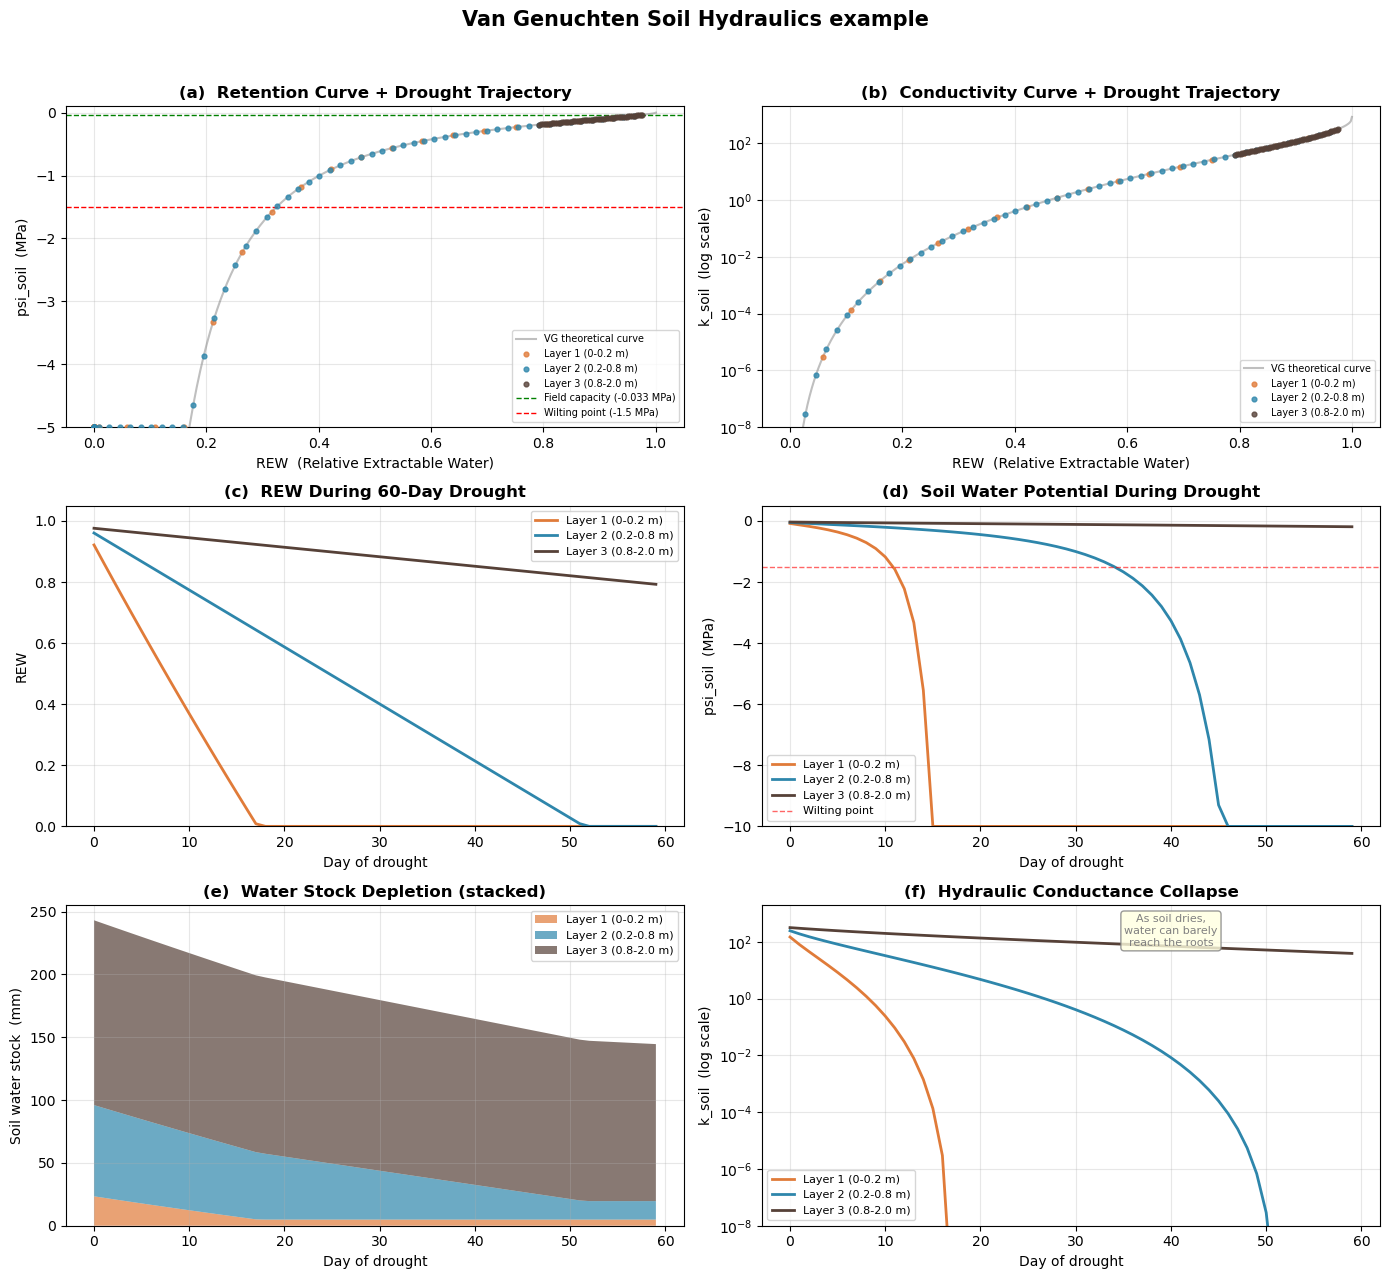

In [ ]:
# | echo: false
days = np.arange(n_days)
layer_labels = ["Layer 1 (0-0.2 m)", "Layer 2 (0.2-0.8 m)", "Layer 3 (0.8-2.0 m)"]
layer_colors = ["#E07B39", "#2E86AB", "#564138"]

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
fig.suptitle(
    "Van Genuchten Soil Hydraulics example", fontsize=15, fontweight="bold", y=0.98
)

# Panel A — Theoretical curve + drought simulation overlay
ax = axes[0, 0]
ax.plot(
    REW_sweep,
    psi_sweep,
    color="gray",
    linewidth=1.5,
    alpha=0.5,
    label="VG theoretical curve",
)
for lyr in range(3):
    # Clip psi for display (very dry layers produce extreme values)
    psi_clipped = np.clip(ts_psi[:, lyr], -5, 0)
    ax.scatter(
        ts_REW[:, lyr],
        psi_clipped,
        color=layer_colors[lyr],
        s=12,
        zorder=3,
        label=layer_labels[lyr],
        alpha=0.8,
    )
ax.set_xlabel("REW  (Relative Extractable Water)")
ax.set_ylabel("psi_soil  (MPa)")
ax.set_title("(a)  Retention Curve + Drought Trajectory", fontweight="bold")
ax.set_ylim(-5, 0.1)
ax.axhline(-0.033, color="green", ls="--", lw=1, label="Field capacity (-0.033 MPa)")
ax.axhline(-1.5, color="red", ls="--", lw=1, label="Wilting point (-1.5 MPa)")
ax.legend(fontsize=7, loc="lower right")
ax.grid(True, alpha=0.3)

# Panel B — Theoretical curve + drought simulation overlay
ax = axes[0, 1]
ax.semilogy(
    REW_sweep,
    k_sweep,
    color="gray",
    linewidth=1.5,
    alpha=0.5,
    label="VG theoretical curve",
)
for lyr in range(3):
    k_vals = np.where(ts_k[:, lyr] > 0, ts_k[:, lyr], 1e-15)
    ax.scatter(
        ts_REW[:, lyr],
        k_vals,
        color=layer_colors[lyr],
        s=12,
        zorder=3,
        label=layer_labels[lyr],
        alpha=0.8,
    )
ax.set_xlabel("REW  (Relative Extractable Water)")
ax.set_ylabel("k_soil  (log scale)")
ax.set_title("(b)  Conductivity Curve + Drought Trajectory", fontweight="bold")
ax.set_ylim(bottom=1e-8, top=2e3)
ax.legend(fontsize=7, loc="lower right")
ax.grid(True, alpha=0.3, which="both")

# Panel C
ax = axes[1, 0]
for lyr in range(3):
    ax.plot(
        days,
        ts_REW[:, lyr],
        color=layer_colors[lyr],
        linewidth=2,
        label=layer_labels[lyr],
    )
ax.set_xlabel("Day of drought")
ax.set_ylabel("REW")
ax.set_title("(c)  REW During 60-Day Drought", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

# Panel D
ax = axes[1, 1]
for lyr in range(3):
    ax.plot(
        days,
        np.clip(ts_psi[:, lyr], -10, 0),
        color=layer_colors[lyr],
        linewidth=2,
        label=layer_labels[lyr],
    )
ax.axhline(-1.5, color="red", ls="--", lw=1, alpha=0.6, label="Wilting point")
ax.set_xlabel("Day of drought")
ax.set_ylabel("psi_soil  (MPa)")
ax.set_title("(d)  Soil Water Potential During Drought", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(-10, 0.5)

# Panel E
ax = axes[2, 0]
ax.stackplot(
    days,
    ts_stock[:, 0],
    ts_stock[:, 1],
    ts_stock[:, 2],
    labels=layer_labels,
    colors=layer_colors,
    alpha=0.7,
)
ax.set_xlabel("Day of drought")
ax.set_ylabel("Soil water stock  (mm)")
ax.set_title("(e)  Water Stock Depletion (stacked)", fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)

# Panel F
ax = axes[2, 1]
for lyr in range(3):
    k_plot = np.where(ts_k[:, lyr] > 0, ts_k[:, lyr], 1e-15)
    ax.semilogy(
        days, k_plot, color=layer_colors[lyr], linewidth=2, label=layer_labels[lyr]
    )
ax.set_xlabel("Day of drought")
ax.set_ylabel("k_soil  (log scale)")
ax.set_title("(f)  Hydraulic Conductance Collapse", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which="both")
ax.set_ylim(bottom=1e-8, top=2e3)
ax.text(
    40,
    ts_k[0, 0] * 0.5,
    "As soil dries,\nwater can barely\nreach the roots",
    fontsize=8,
    color="gray",
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.8),
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()